# Reglas de asociación - Market Basket Analysis (Apriori)

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** IA & Big Data · Minería de Datos · Reglas de Asociación (Apriori)

---

**Objetivo:** identificar qué productos se compran juntos en un supermercado para apoyar
decisiones de cross-selling, distribución en el lineal y promociones combinadas
("quien compra A, también compra B").

**Dataset:** 10.000 transacciones simuladas de supermercado (`transaction_id`, `items`,
`n_items`), 25 productos distintos.

**Dos enfoques, de menos a más escalable:**
1. Cálculo manual de support/confidence/lift para **pares** de productos — para entender
   la matemática de las reglas de asociación sin caja negra.
2. Algoritmo **Apriori** (librería `mlxtend`) para encontrar conjuntos frecuentes de
   **3 o más productos**, algo inabordable a mano por el número de combinaciones.

## 1. Fundamentos teóricos: reglas de asociación

### ¿Qué es el análisis de la cesta de la compra?

El **análisis de la cesta de la compra (Basket Analysis)** identifica combinaciones de productos que aparecen juntos en las transacciones. Su objetivo es encontrar **reglas de asociación** que revelen relaciones entre productos ("si se compra A, entonces también se compra B").

### ¿Para qué sirve?

- **Promociones cruzadas:** mejorar campañas de marketing con descuentos en productos relacionados.
- **Merchandising:** optimizar la colocación de productos en el lineal, situando cerca los que se compran juntos.
- **Ticket medio:** aumentar el valor de cada compra mediante recomendaciones relevantes.
- **Conocimiento del cliente:** entender mejor su comportamiento de compra.

### ¿Cómo funciona?

1. Se recopilan las transacciones de los clientes (cada ticket se considera una **cesta**).
2. Se identifican los productos y las combinaciones que aparecen juntos.
3. Se aplican algoritmos de reglas de asociación (**Apriori**, Eclat o FP-Growth) para encontrar patrones relevantes.
4. Se interpretan las reglas y se aplican a la estrategia del negocio.

### Métricas clave

Ejemplo de regla de asociación: si un cliente compra **Mermelada + Pan**, es probable que también compre **Mantequilla**.

| Métrica | Qué mide | Fórmula |
|---|---|---|
| **Support (Soporte)** | Frecuencia con la que aparece la combinación en todas las transacciones | Transacciones que contienen A y B / Total de transacciones |
| **Confidence (Confianza)** | Probabilidad de que se compre B si ya se compró A | Transacciones que contienen A y B / Transacciones que contienen A |
| **Lift (Elevación)** | Qué tan fuerte es la relación respecto al azar | Confidence (A→B) / Support (B) |

*Donde A y B son productos y A→B se lee: "si se compra A, entonces B".*

**Ejemplo con Pasta y Salsa de Tomate** (el mismo par que resulta ser la regla más fuerte en este notebook):

- **Support:** de 1.000 compras, en 100 se compraron Pasta y Salsa de Tomate juntas → Support = 100/1.000 = **10%**. El 10% de todas las cestas contienen ambos productos.
- **Confidence:** de 200 personas que compraron Pasta, 100 compraron también Salsa de Tomate → Confidence = 100/200 = **50%**. El 50% de quienes compran Pasta también compran Salsa de Tomate.
- **Lift:** compara esa confianza con la probabilidad base de comprar Salsa de Tomate. Interpretación:

| Lift | Interpretación |
|---|---|
| < 1 | Asociación negativa |
| = 1 | No existe una asociación relevante |
| > 1 | Asociación positiva |
| > 1,25 | Asociación positiva interesante |
| Mucho > 1 | Asociación especialmente fuerte |

Con estos fundamentos, el resto del notebook aplica primero el cálculo manual de estas tres métricas sobre pares de productos, y después el algoritmo **Apriori** (librería `mlxtend`) para escalar a conjuntos de 3 o más productos.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

# Estilo visual -- sistema de color validado (consejo UX/UI Data)
BACKGROUND    = "#fbfbfb"
PURPLE        = "#7a7bff"
PURPLE_LIGHT  = "#9b9cff"
POSITIVE      = "#6b8158"
NEGATIVE      = "#c34031"
NEUTRAL_BAR   = "#d9d9d9"
NEUTRAL_LINE  = "#8f8c9e"
CONTEXT_LINES = [NEUTRAL_LINE, "#a89a8a", "#7d94a8"]
INK           = "#111111"
MUTED         = "#707070"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 100,
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.family": "sans-serif",
    "font.size": 10,
    "grid.color": "#f0f0f0",
    "grid.linewidth": 0.5,
})

## 2. Carga y exploración del dataset

In [2]:
data = pd.read_excel("transacciones_supermercado.xlsx")

print(f"Transacciones: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Transacciones: 10000 | Columnas: 3


,transaction_id,items,n_items
0,1,"Cereales, Patatas, Queso",3
1,2,"Huevos, Mantequilla, Pan, Pan_Tostado, Pasta, ...",6
2,3,"Cereales, Galletas, Leche, Pan, Pan_Tostado, R...",6
3,4,"Café, Cereales, Galletas, Helado, Leche, Pan, ...",8
4,5,"Atún, Café, Pan, Pizza_Congelada, Queso, Refre...",8


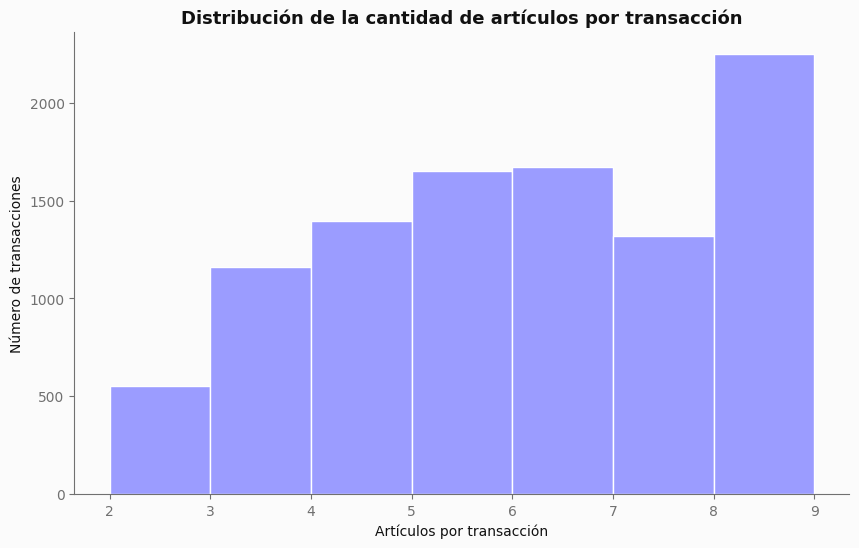

In [3]:
plt.figure(figsize=(10, 6))
plt.hist(
    data["n_items"],
    bins=range(
        data["n_items"].min(),
        data["n_items"].max() + 2
    ),
    color=PURPLE_LIGHT,
    edgecolor="white"
)

plt.title("Distribución de la cantidad de artículos por transacción")
plt.xlabel("Artículos por transacción")
plt.ylabel("Número de transacciones")
plt.show()

## 3. Enfoque manual — support, confidence y lift para pares de productos

Recapitulando lo visto en los fundamentos teóricos, aplicado a un par de productos concreto (A, B):

- **Support(A→B):** en qué fracción de todas las transacciones aparecen A y B juntos.
- **Confidence(A→B):** de las transacciones que tienen A, en qué fracción también aparece B.
- **Lift(A→B):** cuánto más probable es B cuando ya tenemos A, frente a la probabilidad
  base de B (lift > 1 indica asociación positiva real, no casualidad).

In [4]:
# Cada transacción como un set de productos
transactions = [
    set(items.split(", "))
    for items in data["items"]
]

N = len(transactions)
print(f"Total de transacciones: {N}")

Total de transacciones: 10000


In [5]:
# Contar cuántas veces aparece cada producto en todas las transacciones
items_counts = Counter(
    item
    for transaction in transactions
    for item in transaction
)

# Support individual de cada producto
item_support = {
    item: count / N
    for item, count in items_counts.items()
}

support_df = pd.DataFrame(
    list(item_support.items()),
    columns=["Producto", "support"]
).sort_values(by="support", ascending=False).reset_index(drop=True)

support_df

,Producto,support
0,Pan,0.3245
1,Leche,0.3157
2,Fruta,0.3152
3,Huevos,0.3055
4,Café,0.2954
5,Queso,0.2872
6,Cereales,0.2777
7,Verdura,0.2739
8,Mantequilla,0.2469
9,Refrescos,0.2362


In [6]:
# Contador de pares de productos que aparecen juntos en la misma transacción.
#
# El bucle interno debe ir DENTRO del bucle externo (una pasada por transacción):
# si se desindenta, Python solo lo ejecuta una vez con los "items" de la última
# transacción del bucle, subcontando drásticamente los pares reales.

pair_counts = Counter()

for transaction in transactions:
    # Ordenamos los productos de la cesta para que los pares sean consistentes
    items = sorted(transaction)

    # Generamos todas las combinaciones de pares de productos 2 a 2
    for i, producto_a in enumerate(items):
        for producto_b in items[i + 1:]:
            pair_counts[(producto_a, producto_b)] += 1

print(f"Total de pares de productos: {len(pair_counts)}")
print(pair_counts.most_common(10))

Total de pares de productos: 300
[(('Cereales', 'Leche'), 1323), (('Pan', 'Queso'), 1263), (('Café', 'Leche'), 1217), (('Mantequilla', 'Pan'), 1189), (('Huevos', 'Pan'), 1184), (('Fruta', 'Pan'), 963), (('Fruta', 'Huevos'), 955), (('Leche', 'Pan'), 950), (('Fruta', 'Yogur'), 943), (('Fruta', 'Leche'), 937)]


In [7]:
# Calculamos las reglas de asociación y sus métricas para cada par.
# El DataFrame se construye UNA sola vez, al terminar de recorrer todos los pares
# (no dentro del bucle, y no a partir de "rules.append" — eso pasa el propio método
# `list.append` como dato, en vez de la lista `rules` ya rellenada).

rules = []

for (producto_a, producto_b), count_ab in pair_counts.items():
    count_a = items_counts[producto_a]
    count_b = items_counts[producto_b]

    support_ab = count_ab / N

    confidence_a_to_b = count_ab / count_a
    confidence_b_to_a = count_ab / count_b

    lift_a_to_b = confidence_a_to_b / item_support[producto_b]
    lift_b_to_a = confidence_b_to_a / item_support[producto_a]

    rules.append({
        "Producto A": producto_a,
        "Producto B": producto_b,
        "Support": support_ab,
        "Confidence A->B": confidence_a_to_b,
        "Confidence B->A": confidence_b_to_a,
        "Lift A->B": lift_a_to_b,
        "Lift B->A": lift_b_to_a
    })

rules_df = pd.DataFrame(rules)
print(f"Total de reglas generadas: {len(rules_df)}")
rules_df.sort_values("Lift A->B", ascending=False).head(10)

Total de reglas generadas: 300


,Producto A,Producto B,Support,Confidence A->B,Confidence B->A,Lift A->B,Lift B->A
17,Pasta,Salsa_Tomate,0.0894,0.425309,0.408779,1.944715,1.944715
154,Chocolate,Helado,0.0462,0.296534,0.299223,1.920557,1.920557
70,Pizza_Congelada,Refrescos,0.0544,0.408408,0.230313,1.729079,1.729079
117,Cerveza,Patatas,0.0785,0.397670,0.336332,1.703812,1.703812
75,Queso,Vino,0.0783,0.272632,0.471119,1.640387,1.640387
9,Mantequilla,Pan_Tostado,0.0733,0.296881,0.401204,1.624966,1.624966
180,Arroz,Pollo,0.0566,0.319053,0.277451,1.563985,1.563985
19,Cereales,Leche,0.1323,0.476413,0.419069,1.509070,1.509070
8,Mantequilla,Pan,0.1189,0.481571,0.366410,1.484042,1.484042
225,Fruta,Yogur,0.0943,0.299175,0.446496,1.416549,1.416549


### Nota metodológica: ¿qué dirección de la regla es la correcta?

El bucle que genera `pair_counts` ordena cada par alfabéticamente (`Producto A` es siempre el que va primero en el alfabeto), lo cual es arbitrario y no tiene ningún significado de negocio. Filtrar solo por `Confidence A->B` comprobaría siempre esa dirección alfabética — no la dirección realmente fuerte del par — y podría descartar reglas de negocio válidas donde la dirección útil es en realidad B → A.

Para evitarlo, nos quedamos con la dirección de **mayor confianza** de cada par y la etiquetamos como Antecedente → Consecuente. El Lift no cambia con la dirección: es simétrico (Lift(A→B) = Lift(B→A) matemáticamente, porque ambos son la misma probabilidad conjunta dividida por el producto de las probabilidades individuales), así que no hace falta corregirlo.

In [8]:
# Umbrales de negocio:
# - MIN_SUPPORT = 0.08 -> la regla debe aparecer en al menos el 8% de las cestas (con
#   10.000 transacciones son ~800 casos: suficientes para confiar en el patron, no una
#   casualidad de un puñado de tickets).
# - MIN_CONFIDENCE = 0.35 -> muy por encima del soporte medio de un producto suelto
#   (~24%, ver support_df): exige que la regla prediga mejor que la frecuencia base media.
# - MIN_LIFT = 1.15 -> al menos un 15% mas probable que por azar. Es un listón algo mas
#   permisivo que el ">1,25 = asociacion positiva interesante" de la Sección 1: se usa 1.15
#   a proposito para no descartar reglas moderadas que ya superan holgadamente support y
#   confidence.
MIN_SUPPORT = 0.08
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.15

# Nos quedamos con la dirección de mayor confianza de cada par (no la alfabética por
# defecto) — ver nota metodológica arriba.
rules_df["Antecedente"] = rules_df.apply(
    lambda r: r["Producto A"] if r["Confidence A->B"] >= r["Confidence B->A"] else r["Producto B"],
    axis=1
)
rules_df["Consecuente"] = rules_df.apply(
    lambda r: r["Producto B"] if r["Confidence A->B"] >= r["Confidence B->A"] else r["Producto A"],
    axis=1
)
rules_df["Confidence"] = rules_df[["Confidence A->B", "Confidence B->A"]].max(axis=1)

rules_filtered = rules_df[
    (rules_df["Support"] >= MIN_SUPPORT) &
    (rules_df["Confidence"] >= MIN_CONFIDENCE) &
    (rules_df["Lift A->B"] >= MIN_LIFT)
][
    ["Antecedente", "Consecuente", "Support", "Confidence", "Lift A->B"]
].rename(columns={"Lift A->B": "Lift"}).sort_values("Lift", ascending=False).reset_index(drop=True)

print(f"Reglas por encima de los umbrales: {len(rules_filtered)}")
rules_filtered

Reglas por encima de los umbrales: 8


,Antecedente,Consecuente,Support,Confidence,Lift
0,Pasta,Salsa_Tomate,0.0894,0.425309,1.944715
1,Cereales,Leche,0.1323,0.476413,1.509070
2,Mantequilla,Pan,0.1189,0.481571,1.484042
3,Yogur,Fruta,0.0943,0.446496,1.416549
4,Galletas,Café,0.0830,0.407462,1.379357
5,Queso,Pan,0.1263,0.439763,1.355203
6,Café,Leche,0.1217,0.411984,1.304985
7,Huevos,Pan,0.1184,0.387561,1.194334


## 4. Visualización interactiva de las reglas filtradas

In [9]:
import plotly.express as px

rules_filtered["regla"] = (
    rules_filtered["Antecedente"]
    + " → "
    + rules_filtered["Consecuente"]
)

fig = px.scatter(
    rules_filtered,
    x="Support",
    y="Confidence",
    size="Lift",
    hover_name="regla",
    hover_data={
        "Support": ":.3f",
        "Confidence": ":.3f",
        "Lift": ":.3f",
        "Antecedente": True,
        "Consecuente": True
    },
    title="Reglas de asociación filtradas: Support vs Confidence (tamaño = Lift)",
    labels={
        "Support": "Support",
        "Confidence": "Confidence",
        "Lift": "Lift"
    }
)

fig.update_traces(marker=dict(color=PURPLE, opacity=0.75, line=dict(color="white", width=0.5)))
fig.update_layout(
    width=1000, height=650, hovermode="closest",
    paper_bgcolor=BACKGROUND, plot_bgcolor=BACKGROUND,
    font_color=INK
)
fig.show()

## 5. Enfoque profesional — Apriori con mlxtend (conjuntos de 3 o más productos)

El cálculo manual de pares no escala: para conjuntos de 3+ productos el número de
combinaciones crece factorialmente. El algoritmo **Apriori** poda el espacio de búsqueda
usando la propiedad de que un conjunto solo puede ser frecuente si todos sus subconjuntos
también lo son, lo que lo hace viable en la práctica.

In [10]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Convertir cada transacción a lista de productos
transactions_list = data["items"].apply(lambda x: x.split(", ")).tolist()

# One-hot encoding: una columna booleana por producto
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)

basket_encoded = pd.DataFrame(te_ary, columns=te.columns_)
basket_encoded.head()

,Arroz,Atún,Café,Cereales,Cerveza,Chocolate,Fruta,Galletas,Helado,Huevos,...,Patatas,Pizza_Congelada,Pollo,Queso,Refrescos,Salsa_Tomate,Té,Verdura,Vino,Yogur
0,False,False,False,True,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
3,False,False,True,True,False,False,False,True,True,False,...,False,False,True,False,False,True,False,False,False,False
4,False,True,True,False,False,False,False,False,False,False,...,False,True,False,True,True,False,False,True,True,False


In [11]:
# Conjuntos frecuentes de cualquier tamaño (hasta 5 productos)
frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.03,
    use_colnames=True,
    max_len=5
)

frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)

print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
frequent_itemsets.sort_values("support", ascending=False).head(10)

Conjuntos frecuentes encontrados: 296


,support,itemsets,itemset_size
12,0.3245,(Pan),1
10,0.3157,(Leche),1
6,0.3152,(Fruta),1
9,0.3055,(Huevos),1
2,0.2954,(Café),1
18,0.2872,(Queso),1
3,0.2777,(Cereales),1
22,0.2739,(Verdura),1
11,0.2469,(Mantequilla),1
19,0.2362,(Refrescos),1


In [12]:
# Reglas de asociación a partir de todos los conjuntos frecuentes
rules_multi = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

rules_multi["antecedent_size"] = rules_multi["antecedents"].apply(len)
rules_multi["consequent_size"] = rules_multi["consequents"].apply(len)
rules_multi["total_items"] = (
    rules_multi["antecedent_size"] + rules_multi["consequent_size"]
)

# Nos quedamos con las reglas que combinan 3 o más productos en total
rules_3plus = rules_multi[
    rules_multi["total_items"] >= 3
].sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Reglas con 3+ productos: {len(rules_3plus)}")

Reglas con 3+ productos: 118


In [13]:
rules_3plus_accionables = rules_3plus[
    rules_3plus["confidence"] >= MIN_CONFIDENCE
].sort_values("lift", ascending=False).reset_index(drop=True)

print(
    f"Reglas con 3+ productos por encima de {MIN_CONFIDENCE:.0%} de confianza: "
    f"{len(rules_3plus_accionables)} de {len(rules_3plus)}"
)

Reglas con 3+ productos por encima de 35% de confianza: 49 de 118


### Reglas accionables (filtrando por confianza)

El Lift es simétrico (Lift(A→B) = Lift(B→A)), así que al ordenar por lift aparecen **ambas direcciones** de cada asociación — incluida la dirección débil. Por ejemplo, una regla como `{Mantequilla} → {Pan, Pan_Tostado}` puede tener un lift alto pero una confianza baja, porque es la dirección inversa de una asociación mucho más fiable en el otro sentido — poco útil como recomendación de negocio tal cual.

Para quedarnos solo con reglas realmente accionables, aplicamos el mismo umbral de confianza de la Sección 3 (`MIN_CONFIDENCE`).

In [14]:
def convertir_regla(conjunto):
    return ", ".join(sorted(conjunto))


rules_3plus_accionables["antecedent"] = rules_3plus_accionables["antecedents"].apply(convertir_regla)
rules_3plus_accionables["consequent"] = rules_3plus_accionables["consequents"].apply(convertir_regla)

rules_3plus_accionables["regla"] = (
    "{" + rules_3plus_accionables["antecedent"] + "}"
    + " → "
    + "{" + rules_3plus_accionables["consequent"] + "}"
)

rules_3plus_accionables[
    [
        "regla",
        "support",
        "confidence",
        "lift",
        "antecedent_size",
        "consequent_size",
        "total_items"
    ]
].head(20)

,regla,support,confidence,lift,antecedent_size,consequent_size,total_items
0,"{Pan, Pan_Tostado} → {Mantequilla}",0.0336,0.533333,2.160119,2,1,3
1,"{Pan, Vino} → {Queso}",0.0318,0.584559,2.035372,2,1,3
2,"{Mantequilla, Queso} → {Pan}",0.0426,0.597475,1.841219,2,1,3
3,"{Café, Cereales} → {Leche}",0.0478,0.571087,1.808955,2,1,3
4,"{Galletas, Leche} → {Café}",0.0328,0.500000,1.692620,2,1,3
5,"{Huevos, Mantequilla} → {Pan}",0.0421,0.541828,1.669730,2,1,3
6,"{Huevos, Queso} → {Pan}",0.0469,0.502141,1.547431,2,1,3
7,"{Cereales, Mantequilla} → {Leche}",0.0304,0.477987,1.514056,2,1,3
8,"{Leche, Pan} → {Mantequilla}",0.0348,0.366316,1.483661,2,1,3
9,"{Huevos, Leche} → {Cereales}",0.0374,0.409190,1.473498,2,1,3


## 6. Conclusión

> **El hallazgo:** el cálculo manual de pares identifica 300 combinaciones posibles, de las que **8** superan los umbrales de negocio (support ≥ 0,08, confidence ≥ 0,35, lift ≥ 1,15) tras corregir la dirección de la regla — la más fuerte sigue siendo **Pasta → Salsa de Tomate (lift 1,94)**, y la corrección añade dos reglas que el filtro alfabético original pasaba por alto: **Yogur → Fruta** y **Galletas → Café**. Al escalar a conjuntos de 3+ productos con Apriori aparecen 118 reglas candidatas, de las que **49** superan el mismo umbral de confianza y se consideran accionables; la más fuerte es **{Pan, Pan Tostado} → Mantequilla (lift 2,16)**.

**Recomendaciones:**

1. **Colocación en el lineal:** priorizar las reglas con mayor lift entre las 8 (pares) y 49 (tríos) que ya superan el umbral de confianza — son las asociaciones que menos ocurrirían por azar y que además son fiables como predicción direccional.
2. **Promociones cruzadas:** reglas como {Café, Cereales} → Leche (confianza 57%, lift 1,81) identifican qué segundo/tercer producto conviene promocionar cuando el cliente ya lleva los primeros en la cesta — más rentable que descontar productos sueltos.
3. **Escalar con Apriori, no a mano:** el cálculo manual de pares ya generó 300 combinaciones con solo 25 productos — para conjuntos de 3+ productos el crecimiento es factorial, por lo que Apriori es imprescindible en catálogos reales (cientos o miles de referencias).
4. **Dirección de la regla:** conviene comprobar siempre la confianza en ambos sentidos antes de actuar sobre una regla — el lift no distingue la dirección útil de la inútil, solo la confianza lo hace (ver nota metodológica de la Sección 3). Ignorar esto costó 2 de las 8 reglas de pares en la primera versión de este análisis.
5. **Comparaciones múltiples:** se evaluaron 300 pares y 118 combinaciones de 3+ productos — con tantas pruebas simultáneas, alguna asociación puede superar los umbrales por azar. Los datos aquí son sintéticos, pero en un caso real conviene validar las reglas más importantes con un test estadístico (p. ej., chi-cuadrado) o con datos de un periodo distinto antes de tomar decisiones de inventario.
6. **Limitación:** el dataset es sintético y no captura estacionalidad ni promociones activas — antes de fijar el layout de tienda conviene validar estas reglas con datos reales de varios meses.